In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [10]:
print(y_train[:3])

[5 0 4]


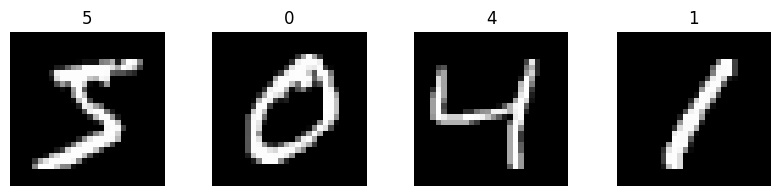

In [13]:
plt.figure(figsize=(10,2))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

In [14]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

E:\Python\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9259 - loss: 0.2584
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9669 - loss: 0.1133
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9765 - loss: 0.0785
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0590
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0453
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9890 - loss: 0.0366
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9911 - loss: 0.0288
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9930 - loss: 0.0227
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9941 - loss: 0.0198
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9948 - loss: 0.0165


In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy =", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9762 - loss: 0.0891
Accuracy = 0.9761999845504761


In [18]:
y_pred = model.predict(X_test)
pred = np.argmax(y_pred, axis=1)
print(pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 0 4 1 4 9 5 9]


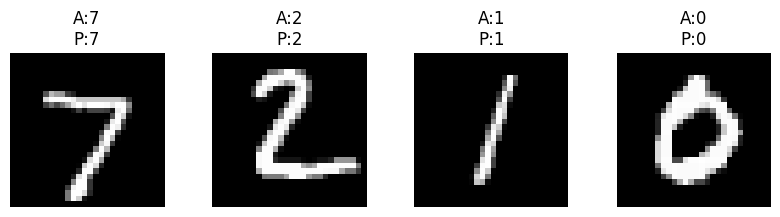

In [19]:
plt.figure(figsize=(10,2))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("A:"+str(y_test[i])+"\nP:"+str(pred[i]))
    plt.axis("off")
plt.show()


True Predictions: 238


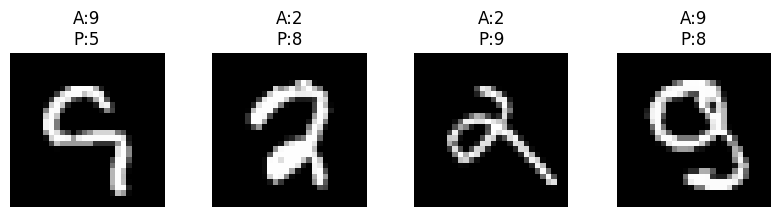

In [21]:
true = np.where(pred != y_test)[0]
print("True Predictions:", len(true))
plt.figure(figsize=(10,2))
for i in range(4):
    j = wrong[i]
    plt.subplot(1,4,i+1)
    plt.imshow(X_test[j], cmap="gray")
    plt.title("A:"+str(y_test[j])+"\nP:"+str(pred[j]))
    plt.axis("off")
plt.show()